In [877]:
import torch , numpy as np, pandas as pd

In [878]:
np.set_printoptions(linewidth=140)
torch.set_printoptions(linewidth=140,sci_mode=False,edgeitems=7)
pd.set_option('display.width', 140)

In [879]:
df=pd.read_csv(r'C:\Users\enesm\OneDrive\Masaüstü\My_Deep_Learning_Journey\FastAi\titanic_data\titanic_train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [880]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [881]:
modes=df.mode().iloc[0]
modes

PassengerId                      1
Survived                       0.0
Pclass                         3.0
Name           Abbing, Mr. Anthony
Sex                           male
Age                           24.0
SibSp                          0.0
Parch                          0.0
Ticket                        1601
Fare                          8.05
Cabin                      B96 B98
Embarked                         S
Name: 0, dtype: object

In [882]:
df.fillna(modes,inplace=True)

In [883]:
df.describe(include=np.number)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,28.566970,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.199572,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,24.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: >

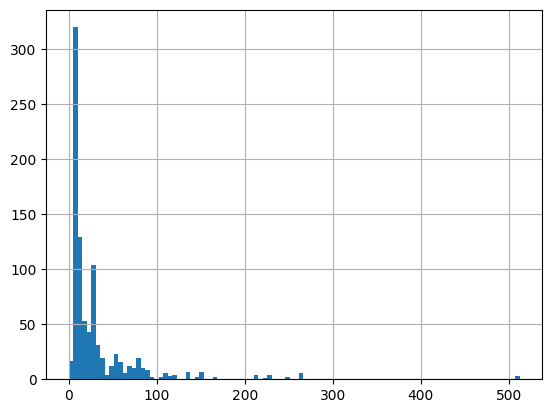

In [884]:
df['Fare'].hist(bins=100)

In [885]:
df['LogFare']=np.log(df['Fare']+1) 

<Axes: >

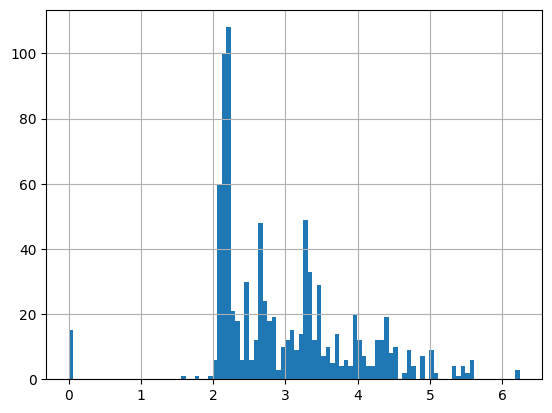

In [886]:
df['LogFare'].hist(bins=100)

In [887]:
df = pd.get_dummies(df, columns=["Sex","Pclass","Embarked"])
df.columns

Index(['PassengerId', 'Survived', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'LogFare', 'Sex_female', 'Sex_male',
       'Pclass_1', 'Pclass_2', 'Pclass_3', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [888]:
added_cols = ['Sex_male', 'Sex_female', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Embarked_C', 'Embarked_Q', 'Embarked_S']
df[added_cols]=df[added_cols].astype(int)

In [889]:
df.describe(include=object)

,Name,Ticket,Cabin
count,891,891,891
unique,891,681,147
top,"Braund, Mr. Owen Harris",347082,B96 B98
freq,1,7,691


In [890]:
from torch import tensor
t_dep=tensor(df.Survived)

In [891]:
t_dep

tensor([0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
        1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
        0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
        1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
        0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
        0, 1, 1, 1, 

In [892]:
df.columns

Index(['PassengerId', 'Survived', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'LogFare', 'Sex_female', 'Sex_male',
       'Pclass_1', 'Pclass_2', 'Pclass_3', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [893]:
indep_cols=['Age', 'SibSp', 'Parch', 'Fare', 'LogFare', 'Sex_female', 'Sex_male',
       'Pclass_1', 'Pclass_2', 'Pclass_3', 'Embarked_C', 'Embarked_Q', 'Embarked_S']
t_indep=tensor(df[indep_cols].values,dtype=torch.float)

In [894]:
t_indep.shape

torch.Size([891, 13])

In [895]:
#Dimension of the tensor
len(t_indep.shape)


2

# Setting up a Linear Model

In [896]:
n_coeff=t_indep.shape[1]
coeffs=torch.rand(n_coeff)-0.5
coeffs

tensor([-0.1808,  0.4837,  0.4682, -0.2798,  0.2114,  0.0359, -0.1296, -0.2178, -0.0709,  0.2441,  0.1996,  0.0158, -0.3867])

In [897]:
t_indep

tensor([[22.0000,  1.0000,  0.0000,  7.2500,  2.1102,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [38.0000,  1.0000,  0.0000, 71.2833,  4.2806,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000],
        [26.0000,  0.0000,  0.0000,  7.9250,  2.1889,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [35.0000,  1.0000,  0.0000, 53.1000,  3.9908,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000],
        [35.0000,  0.0000,  0.0000,  8.0500,  2.2028,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [24.0000,  0.0000,  0.0000,  8.4583,  2.2469,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000],
        [54.0000,  0.0000,  0.0000, 51.8625,  3.9677,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000],
        ...,
        [25.0000,  0.0000,  0.0000,  7.0500,  2.0857,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,

In [898]:
t_indep*coeffs

tensor([[    -3.9773,      0.4837,      0.0000,     -2.0288,      0.4462,      0.0000,     -0.1296,     -0.0000,     -0.0000,      0.2441,
              0.0000,      0.0000,     -0.3867],
        [    -6.8699,      0.4837,      0.0000,    -19.9471,      0.9051,      0.0359,     -0.0000,     -0.2178,     -0.0000,      0.0000,
              0.1996,      0.0000,     -0.0000],
        [    -4.7005,      0.0000,      0.0000,     -2.2176,      0.4628,      0.0359,     -0.0000,     -0.0000,     -0.0000,      0.2441,
              0.0000,      0.0000,     -0.3867],
        [    -6.3276,      0.4837,      0.0000,    -14.8589,      0.8438,      0.0359,     -0.0000,     -0.2178,     -0.0000,      0.0000,
              0.0000,      0.0000,     -0.3867],
        [    -6.3276,      0.0000,      0.0000,     -2.2526,      0.4657,      0.0000,     -0.1296,     -0.0000,     -0.0000,      0.2441,
              0.0000,      0.0000,     -0.3867],
        [    -4.3389,      0.0000,      0.0000,     -2.3669,

In [899]:
vals,indices=t_indep.max(dim=0)
vals,indices

(tensor([ 80.0000,   8.0000,   6.0000, 512.3292,   6.2409,   1.0000,   1.0000,   1.0000,   1.0000,   1.0000,   1.0000,   1.0000,   1.0000]),
 tensor([630, 159, 678, 258, 258,   1,   0,   1,   9,   0,   1,   5,   0]))

In [900]:
#Standardization
t_indep=t_indep/vals
t_indep

tensor([[0.2750, 0.1250, 0.0000, 0.0142, 0.3381, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.4750, 0.1250, 0.0000, 0.1391, 0.6859, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000],
        [0.3250, 0.0000, 0.0000, 0.0155, 0.3507, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.4375, 0.1250, 0.0000, 0.1036, 0.6395, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.4375, 0.0000, 0.0000, 0.0157, 0.3530, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.3000, 0.0000, 0.0000, 0.0165, 0.3600, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000],
        [0.6750, 0.0000, 0.0000, 0.1012, 0.6358, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        ...,
        [0.3125, 0.0000, 0.0000, 0.0138, 0.3342, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.4875, 0.0000, 0.8333, 0.0568, 0.5456, 1.0000, 0.0000, 0.0000, 0.

In [901]:
x=t_indep*coeffs
x.shape


torch.Size([891, 13])

In [902]:
preds=(t_indep*coeffs).sum(axis=1)
preds

tensor([    -0.1939,      0.0985,     -0.0956,     -0.4810,     -0.2810,      0.1476,     -0.7500,      0.0760,      0.0668,      0.2935,
             0.1110,     -0.6018,     -0.2471,      0.1910,     -0.0688,     -0.4588,      0.5452,     -0.5591,     -0.0264,      0.4929,
            -0.5688,     -0.5817,      0.3321,     -0.6948,      0.2280,      0.3587,      0.3274,     -0.3943,      0.3112,     -0.2567,
            -0.1395,      0.1132,      0.3108,     -0.6593,     -0.0456,     -0.6624,      0.3274,     -0.2494,      0.0635,      0.5872,
            -0.0622,     -0.3290,      0.3297,      0.4788,      0.3225,     -0.2562,      0.2231,      0.3108,      0.4748,      0.0027,
             0.1358,     -0.2502,      0.0731,     -0.3293,     -0.1100,     -0.6858,     -0.3922,      0.3172,     -0.1179,      0.2668,
             0.3319,     -0.5493,     -0.6706,      0.1550,     -0.1033,      0.4846,     -0.4102,     -0.2445,      0.3226,     -0.1379,
            -0.5825,      0.4210, 

In [903]:
preds.shape

torch.Size([891])

In [904]:
t_dep

tensor([0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
        1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
        0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
        1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
        0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
        0, 1, 1, 1, 

In [905]:
loss=torch.abs(t_dep-preds).mean()

In [906]:
loss

tensor(0.6399)

In [907]:
def calc_preds(coeffs,indeps): return (indeps*coeffs).sum(axis=1)
def calc_loss(coeffs,indeps,deps):return torch.abs(calc_preds(coeffs,indeps)-deps).mean()

## Doing a Gradient Descent Step

In [908]:
coeffs.requires_grad_()

tensor([-0.1808,  0.4837,  0.4682, -0.2798,  0.2114,  0.0359, -0.1296, -0.2178, -0.0709,  0.2441,  0.1996,  0.0158, -0.3867],
       requires_grad=True)

In [909]:
loss=calc_loss(coeffs,t_indep,t_dep)
loss

tensor(0.6399, grad_fn=<MeanBackward0>)

In [910]:
loss.backward()

In [911]:
coeffs.grad

tensor([-0.2600, -0.0056, -0.0135, -0.0485, -0.3218, -0.2402, -0.4254, -0.2379, -0.1908, -0.2368, -0.0763,  0.0146, -0.6038])

In [912]:
with torch.no_grad():
    coeffs.sub_(coeffs.grad*0.1)
    print(calc_loss(coeffs,t_indep,t_dep))
    

tensor(0.5523)


## Training the Linear Model

In [913]:
from fastai.data.transforms import RandomSplitter
trn_split,val_split=RandomSplitter(seed=42)(df)

In [914]:
trn_indep,val_indep=t_indep[trn_split],t_indep[val_split]
trn_dep,val_dep=t_dep[trn_split],t_dep[val_split]
len(trn_indep),len(val_indep)

(713, 178)

In [915]:
def update_coeffs(coeffs,lr): return coeffs.sub_(coeffs.grad*lr)

In [916]:
def one_epoch(coeffs,lr):
    loss=calc_loss(coeffs,trn_indep,trn_dep)
    loss.backward()
    with torch.no_grad(): update_coeffs(coeffs,lr)
    print(f"{loss:.3f}",end="; ")

In [917]:
def init_coeffs(): return (torch.rand(n_coeff)-0.5).requires_grad_()

In [918]:
def train_model(epochs=30,lr=0.01):
    torch.manual_seed(41)
    coeffs=init_coeffs()
    for i in range(epochs):one_epoch(coeffs,lr=lr)
    return coeffs

In [919]:
coeffs= train_model(18,lr=0.1)

0.368; 0.346; 0.340; 0.327; 0.303; 0.254; 0.314; 0.361; 0.359; 0.337; 0.353; 0.361; 0.306; 0.341; 0.356; 0.324; 0.334; 0.370; 

In [920]:
def show_coeffs(): return dict(zip(indep_cols,coeffs.requires_grad_(False)))
show_coeffs()

{'Age': tensor(-0.2431),
 'SibSp': tensor(-0.2547),
 'Parch': tensor(0.1970),
 'Fare': tensor(-0.2466),
 'LogFare': tensor(0.0012),
 'Sex_female': tensor(0.2155),
 'Sex_male': tensor(-0.0720),
 'Pclass_1': tensor(0.2893),
 'Pclass_2': tensor(0.4472),
 'Pclass_3': tensor(0.1922),
 'Embarked_C': tensor(0.3480),
 'Embarked_Q': tensor(0.3978),
 'Embarked_S': tensor(0.1588)}

## Measuring Accuracy

In [921]:
preds= calc_preds(coeffs,val_indep)
preds

tensor([ 0.9821,  0.4418,  0.3922,  0.4448,  0.4523,  0.3894,  0.7704,  0.7306,  0.1606,  0.6736,  0.1784,  0.3895,  0.2630,  0.7292,
         0.1730,  0.2272,  0.1664,  0.7664,  0.4037,  0.4685,  0.2027,  0.1938,  0.6827,  0.6789,  0.2153,  0.4023,  0.5595,  0.1755,
         0.2236,  0.7292,  0.8267,  0.4024,  0.2179,  0.1829,  0.9639,  0.4843,  0.2176,  0.7472,  0.2027,  0.4553,  0.4717,  0.2027,
         0.4769,  0.7196,  0.2148,  0.5876,  0.1736,  0.1586,  0.4422,  0.4965,  0.3752,  0.1363,  0.1755,  0.2001,  0.4505,  0.4322,
         0.4418,  0.1309,  0.2118,  0.1852,  0.4614,  0.1925,  0.1192,  0.2118,  0.6441,  0.3087,  0.4554,  0.1495,  0.3906,  0.6788,
         0.1967,  0.7416,  0.4353,  0.2020,  0.2913,  0.2271,  0.2027,  0.1863,  0.4706,  0.3846,  0.4821,  0.6656,  0.2058,  0.2030,
         0.6650,  0.6618,  0.4272,  0.5979,  0.8828,  0.4584,  0.1782,  0.2027,  0.7112,  0.3740,  0.7138,  0.6082,  0.3824,  0.6583,
         0.7353,  0.4575,  0.2220,  0.7292,  0.1784,  0.1845, 

In [922]:
val_dep.bool()

tensor([ True, False, False, False, False, False,  True,  True, False,  True,  True,  True,  True,  True, False,  True, False,  True, False,
         True, False, False,  True,  True, False, False,  True, False, False,  True,  True, False, False, False,  True, False, False,  True,
        False, False,  True, False, False,  True, False, False,  True, False, False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False,  True, False, False, False, False, False, False,  True, False, False, False, False, False, False,
        False,  True, False, False,  True,  True, False, False,  True, False, False,  True,  True, False, False, False,  True, False,  True,
        False, False,  True,  True, False, False,  True, False, False,  True,  True,  True,  True,  True, False,  True, False,  True,  True,
        False,  True, False, False, False,  True, False,  True, False,  True, False, False, False,  True, False, False,  True, False,  True,
         True

In [923]:
results= val_dep.bool()==(preds>0.5)
results

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True, False, False, False,  True,  True, False,  True,  True,  True,
        False,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True, False,  True,  True,  True,  True, False, False,  True,  True, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True, False,  True, False,  True,  True,  True,  True,  True,  True, False,  True,  True,  True,  True,
         True, False,  True,  True, False,  True,  True,  True,  True, False,  True,  True,  True,  True,  True,  True,  True,  True,  True,
        False,  True,  True,  True,  True,  True,  True,  True,  True, False, False, False,  True, False,  True,  True,  True, False,  True,
         True,  True,  True,  True,  True,  True,  True, False,  True, False,  True,  True,  True, False,  True,  True,  True,  True,  True,
         True

In [924]:
results.float().mean()

tensor(0.7865)

In [925]:
def calc_acc(coeffs): return (val_dep.bool()==(calc_preds(coeffs,val_indep)>0.5)).float().mean()
calc_acc(coeffs)

tensor(0.7865)

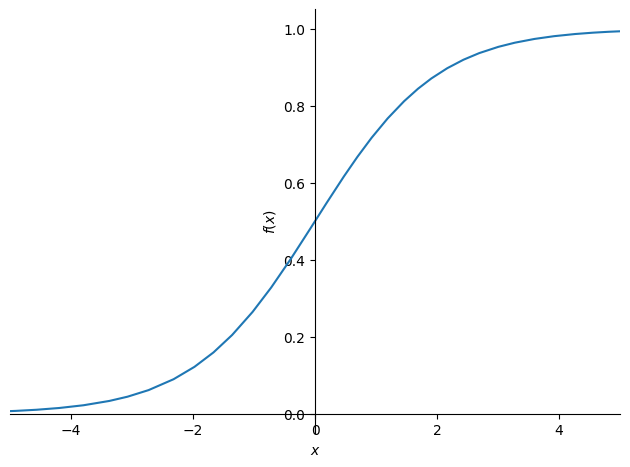

In [926]:
import sympy 
sympy.plot("1/(1+exp(-x))",xlim=(-5,5))

In [927]:
def calc_preds(coeffs,indeps): return torch.sigmoid((indeps*coeffs).sum(axis=1))

In [928]:
coeffs.requires_grad_()

tensor([-0.2431, -0.2547,  0.1970, -0.2466,  0.0012,  0.2155, -0.0720,  0.2893,  0.4472,  0.1922,  0.3480,  0.3978,  0.1588],
       requires_grad=True)

In [929]:
coeffs=train_model(epochs=15,lr=2)

0.472; 0.429; 0.362; 0.311; 0.285; 0.267; 0.251; 0.236; 0.223; 0.214; 0.209; 0.205; 0.204; 0.203; 0.202; 

In [930]:
calc_acc(coeffs)

tensor(0.8258)

In [931]:
show_coeffs()

{'Age': tensor(-1.1028),
 'SibSp': tensor(-0.5985),
 'Parch': tensor(0.3582),
 'Fare': tensor(0.2656),
 'LogFare': tensor(0.4457),
 'Sex_female': tensor(7.3725),
 'Sex_male': tensor(-9.0098),
 'Pclass_1': tensor(3.0845),
 'Pclass_2': tensor(1.3784),
 'Pclass_3': tensor(-5.3150),
 'Embarked_C': tensor(1.2327),
 'Embarked_Q': tensor(0.3377),
 'Embarked_S': tensor(-2.4467)}

# Submitting the Kaggle

In [932]:
tst_df=pd.read_csv(r'C:\Users\enesm\OneDrive\Masaüstü\My_Deep_Learning_Journey\FastAi\titanic_data\titanic_test.csv')

In [933]:
tst_df['Fare'].fillna(0,inplace=True)

In [934]:
tst_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [935]:
tst_df.fillna(modes, inplace=True)
tst_df['LogFare'] = np.log(tst_df['Fare']+1)
tst_df = pd.get_dummies(tst_df, columns=["Sex","Pclass","Embarked"])

In [936]:

tst_df[indep_cols]=tst_df[indep_cols].astype(int)
tst_indep = tensor(tst_df[indep_cols].values, dtype=torch.float)
tst_indep = tst_indep / vals

In [937]:
tst_df['Survived']=(calc_preds(coeffs,tst_indep)>0.5).int()

In [938]:
tst_df

,PassengerId,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,LogFare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S,Survived
0,892,"Kelly, Mr. James",34,0,0,330911,7,B96 B98,2,0,1,0,0,1,0,1,0,0
1,893,"Wilkes, Mrs. James (Ellen Needs)",47,1,0,363272,7,B96 B98,2,1,0,0,0,1,0,0,1,0
2,894,"Myles, Mr. Thomas Francis",62,0,0,240276,9,B96 B98,2,0,1,0,1,0,0,1,0,0
3,895,"Wirz, Mr. Albert",27,0,0,315154,8,B96 B98,2,0,1,0,0,1,0,0,1,0
4,896,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22,1,1,3101298,12,B96 B98,2,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,"Spector, Mr. Woolf",24,0,0,A.5. 3236,8,B96 B98,2,0,1,0,0,1,0,0,1,0
414,1306,"Oliva y Ocana, Dona. Fermina",39,0,0,PC 17758,108,C105,4,1,0,1,0,0,1,0,0,1
415,1307,"Saether, Mr. Simon Sivertsen",38,0,0,SOTON/O.Q. 3101262,7,B96 B98,2,0,1,0,0,1,0,0,1,0
416,1308,"Ware, Mr. Frederick",24,0,0,359309,8,B96 B98,2,0,1,0,0,1,0,0,1,0


In [939]:
sub_df=tst_df[['PassengerId','Survived']]
sub_df.to_csv('sub.csv',index=False)


# Using Matrix Product


In [940]:
coeffs

tensor([-1.1028, -0.5985,  0.3582,  0.2656,  0.4457,  7.3725, -9.0098,  3.0845,  1.3784, -5.3150,  1.2327,  0.3377, -2.4467])

In [941]:
val_indep@coeffs

tensor([  8.9493, -14.1591, -13.2686,  -9.9802, -10.2275, -10.3899,   3.4924,   6.1135, -16.7392,   3.1810, -17.0522, -13.2310, -16.6577,
          2.2244, -17.0929,  -8.7417,  -9.0174,   6.2682, -10.3668,  -0.6499, -16.9421,  -8.8933,  11.5315,   6.0201, -16.8946, -14.1499,
         -0.2340,  -8.9760, -16.8393,   2.2233,   6.3707,  -0.5637, -16.8732, -17.0304,   8.8665,  -0.3322,  -8.7482,  11.6986, -16.9408,
         -0.6482, -10.1601, -16.9408, -10.2130,  11.5987, -16.8857,  -0.3706, -16.8112, -16.9220, -14.1663,  -0.5380,  -5.9749, -16.8495,
        -16.8107, -16.9635, -10.2566, -10.3393, -14.1590, -17.1340, -16.8995, -16.9532,  -4.8518, -16.9280,  -9.2140, -16.9005,   5.8717,
         -8.2503, -10.2137, -17.0662, -14.3453,   5.8819, -16.9697,   3.2858, -10.3255, -16.9294,  -8.4542, -16.8329, -16.9408,  -8.6018,
        -10.1448, -10.5202,  -9.8981,  11.9042, -16.9283, -16.9478,   5.7949,  -6.4092,  -4.6234,   8.2667,   9.7652, -10.1999, -17.0485,
        -16.9408,  11.6654, -13.35

In [942]:
trn_indep@coeffs

tensor([-16.5106, -14.3864, -16.9772, -17.0487,  -0.3633,   6.1341,  11.5848, -16.9973, -16.9976,  -7.9024,  -8.6047, -10.3807, -16.9421,
        -16.8222,   6.0032,   2.2233,   6.0154,  -0.5585,  -8.8184, -10.3210, -10.5886,  11.1943, -16.9477, -16.9478, -17.0528, -17.2165,
         -0.5458, -17.0672, -10.1712,   8.1228, -16.8581,  -0.6113,   6.3509,   7.8418, -16.9451,  -4.6691, -16.8867,  -9.8818, -17.0334,
         -4.4414,   6.5342,   7.9610,  -0.4984,  -0.4322,   6.4429,   8.1028, -16.9472, -17.2707,  -4.7951, -17.2649, -17.0116,  -8.7028,
         -0.6009, -16.8763, -17.0235, -17.0599,  -8.6184, -16.8305, -16.9421,   6.1796, -10.1398, -16.9030,   2.1978,  -4.5175, -10.4205,
         -6.0140,   8.0241,   2.3336,  -8.4826,  -0.5871,   2.2244,  11.5436, -10.5445, -16.9408,  -4.7950, -10.2709,  11.5398,  -4.9897,
         -8.7830,  -0.4350, -10.4799, -10.3899,  -0.2455,   6.0843,   3.3581,  11.7233, -10.6484,  -8.6963, -16.9580, -10.2755, -17.4469,
         -4.4529, -10.2964, -13.22

In [943]:
def calc_preds(coeffs,indeps): return torch.sigmoid(indeps@coeffs)

In [944]:
def init_coeffs(): return (torch.rand(n_coeff,1)*0.1).requires_grad_()

In [945]:
trn_dep=trn_dep[:,None]
val_dep=val_dep[:,None]

In [946]:
coeffs=train_model(epochs=25,lr=1)

0.508; 0.487; 0.445; 0.390; 0.343; 0.313; 0.294; 0.281; 0.269; 0.257; 0.245; 0.233; 0.224; 0.216; 0.211; 0.208; 0.205; 0.204; 0.203; 0.203; 0.202; 0.203; 0.203; 0.203; 0.203; 

In [865]:
calc_acc(coeffs)

tensor(0.8146)

# Neural Network

In [866]:
const=torch.rand(1)[0]
const

tensor(0.5407)

In [867]:
def init_coeffs(n_hidden=20):
    layer1=(torch.rand(n_coeff,n_hidden)-0.5)/n_hidden
    layer2=torch.rand(n_hidden,1)-0.3
    const=torch.rand(1)[0]
    return layer1.requires_grad_(),layer2.requires_grad_(),const.requires_grad_()

In [868]:
coeffs=init_coeffs()

In [869]:
l1,l2,const=coeffs

In [870]:
l1.shape

torch.Size([13, 20])

In [871]:
l2.shape

torch.Size([20, 1])

In [872]:
(l1@l2).shape

torch.Size([13, 1])

In [873]:
import torch.nn.functional as F

def calc_preds(coeffs,indeps):
    l1,l2,const=coeffs
    res=F.relu(indeps@l1)
    res=res@l2+const
    return torch.sigmoid(res)

In [874]:
def update_coeffs(coeffs,lr):
    for layer in coeffs: layer.sub_(layer.grad*lr)

In [875]:
coeffs=train_model(lr=1.4)

0.517; 0.505; 0.485; 0.450; 0.399; 0.334; 0.275; 0.233; 0.215; 0.212; 0.212; 0.213; 0.213; 0.214; 0.214; 0.214; 0.214; 0.214; 0.214; 0.214; 0.213; 0.210; 0.195; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 

In [876]:
coeffs

(tensor([[     0.3779,     -0.1134,      0.0431,      1.4395,      0.5797,      1.0018,     -0.0480,      0.6002,     -0.0022,      1.2404,
               0.4526,      0.4748,      0.0189,      0.0058,      0.1731,     -0.3736,      0.5687,     -0.1063,      0.9707,     -0.0244],
         [    -0.1037,      0.0277,     -0.0169,      0.8146,     -0.1356,      0.5343,     -0.0197,     -0.2193,     -0.0125,     -0.3623,
              -0.0784,     -0.3609,     -0.0012,     -0.0033,     -0.0965,     -0.0606,      0.3072,     -0.0105,      0.5552,     -0.0081],
         [     0.0287,      0.0141,     -0.0039,      0.4245,      0.0496,      0.3143,      0.0237,     -0.0420,      0.0035,      0.0059,
              -0.0235,     -0.1224,     -0.0003,     -0.0214,     -0.0475,     -0.0758,      0.1737,     -0.0029,      0.3164,      0.0006],
         [     0.2600,     -0.0665,     -0.0412,     -0.0535,      0.4594,     -0.0703,      0.0035,      0.3731,      0.0575,      0.7932,
               0.

In [789]:
calc_acc(coeffs)

tensor(0.8258)

## Deep Learning

In [952]:
def init_coeffs():
    hiddens = [10, 10]  # <-- set this to the size of each hidden layer you want
    sizes = [n_coeff] + hiddens + [1]
    n = len(sizes)
    layers = [(torch.rand(sizes[i], sizes[i+1])-0.3)/sizes[i+1]*4 for i in range(n-1)]
    consts = [(torch.rand(1)[0]-0.5)*0.1 for i in range(n-1)]
    for l in layers+consts: l.requires_grad_()
    return layers,consts

In [953]:
import torch.nn.functional as F

def calc_preds(coeffs, indeps):
    layers,consts = coeffs
    n = len(layers)
    res = indeps
    for i,l in enumerate(layers):
        res = res@l + consts[i]
        if i!=n-1: res = F.relu(res)
    return torch.sigmoid(res)

In [954]:
def update_coeffs(coeffs, lr):
    layers,consts = coeffs
    for layer in layers+consts:
        layer.sub_(layer.grad * lr)
        layer.grad.zero_()

In [959]:
coeffs = train_model(epochs=200,lr=0.5)

0.606; 0.576; 0.494; 0.488; 0.478; 0.469; 0.487; 0.480; 0.459; 0.459; 0.481; 0.479; 0.477; 0.476; 0.474; 0.472; 0.470; 0.468; 0.464; 0.456; 0.441; 0.409; 0.388; 0.391; 0.373; 0.379; 0.354; 0.360; 0.332; 0.338; 0.313; 0.306; 0.288; 0.279; 0.270; 0.263; 0.257; 0.251; 0.246; 0.242; 0.239; 0.236; 0.234; 0.231; 0.229; 0.228; 0.226; 0.225; 0.224; 0.223; 0.222; 0.221; 0.220; 0.219; 0.218; 0.217; 0.216; 0.215; 0.214; 0.213; 0.212; 0.211; 0.210; 0.210; 0.209; 0.208; 0.207; 0.207; 0.206; 0.206; 0.205; 0.204; 0.204; 0.203; 0.203; 0.203; 0.202; 0.202; 0.202; 0.201; 0.201; 0.201; 0.200; 0.200; 0.200; 0.200; 0.199; 0.199; 0.199; 0.199; 0.199; 0.198; 0.198; 0.198; 0.198; 0.198; 0.198; 0.198; 0.197; 0.197; 0.197; 0.197; 0.197; 0.197; 0.197; 0.197; 0.197; 0.197; 0.196; 0.196; 0.196; 0.196; 0.196; 0.196; 0.196; 0.196; 0.196; 0.196; 0.196; 0.196; 0.196; 0.196; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195;

In [960]:
calc_acc(coeffs)

tensor(0.8258)